# NB-02: 統合回帰モデル推定

**目的**: OLS回帰で β₁(ペース)・β₂(TSI)・β₃(斤量)・β₄(レースレベル)および
固定効果（par_time）を同時推定し、STG DBの `megu_regression_params` / `megu_par_time` に保存する。

## 仕様
- 推定方式: OLS + HC3 ロバスト標準誤差 (U-4)
- VIF ≥ 5 時のみ Ridge に切替
- 学習データ: 2020-2024 年（テンポラルリーク防止）
- `Δlevel = 0`（FQ: 獲得賞金データ未入力のため、係数枠は保持）


In [1]:
import sys, warnings, json
sys.path.insert(0, '/home/jovyan/work/keiba-vpn')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

INPUT_DIR  = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01')
OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup OK')


Setup OK


## 1. データロード（2020-2024 学習データ）

In [2]:
df_all = pd.read_parquet(INPUT_DIR / 'megu_dataset.parquet')
df_par_splits = pd.read_parquet(INPUT_DIR / 'par_splits.parquet')

# 学習データ: 2020-2024
df_train = df_all[df_all['year'].isin([2020,2021,2022,2023,2024])].copy()
print(f'学習データ: {len(df_train):,} 行  (2020-2024)')
print(f'surface: {df_train["surface"].value_counts().to_dict()}')
print(f'track_cat: {df_train["track_cat"].value_counts().to_dict()}')

# par_splits マージ → front_split_dev 計算
df_train = df_train.merge(
    df_par_splits[['distance','surface','track_cat','par_front_split_final']].rename(
        columns={'par_front_split_final':'par_front_split_sec'}),
    on=['distance','surface','track_cat'], how='left'
)
df_train['front_split_dev'] = df_train['front_split_sec'] - df_train['par_front_split_sec']
print(f'\nfront_split_dev カバレッジ: {df_train["front_split_dev"].notna().mean():.1%}')
print(f'front_split_dev 統計:')
print(df_train['front_split_dev'].describe())

# ── 【最適化】2着基準フィルタ ─────────────────────────────────────────────
# 各レースの2着タイムを取得（なければ1着タイムで代用）
df_2nd_ref = (
    df_train[df_train['finish_pos'] == 2][['race_id','finish_time_sec']]
    .rename(columns={'finish_time_sec': 'time_2nd'})
)
df_1st_ref = (
    df_train[df_train['finish_pos'] == 1][['race_id','finish_time_sec']]
    .rename(columns={'finish_time_sec': 'time_2nd_fallback'})
)
df_2nd_ref = df_2nd_ref.merge(df_1st_ref, on='race_id', how='outer')
df_2nd_ref['time_2nd'] = df_2nd_ref['time_2nd'].fillna(df_2nd_ref['time_2nd_fallback'])

df_train = df_train.merge(df_2nd_ref[['race_id','time_2nd']], on='race_id', how='left')

# 1・2着は常に含む / 3着以降は 2着タイム+2秒以内のみ
mask_valid = (df_train['finish_pos'] <= 2) | (
    df_train['finish_time_sec'] <= (df_train['time_2nd'].fillna(np.inf) + 2.0)
)
n_before = len(df_train)
df_train = df_train[mask_valid].copy()
n_out = n_before - len(df_train)
print(f'2着基準フィルタ: {n_before:,} → {len(df_train):,} (除外: {n_out:,}, {n_out/n_before:.1%})')


学習データ: 175,472 行  (2020-2024)
surface: {'芝': 102991, 'ダート': 72481}
track_cat: {'良': 125936, '稍重': 28500, '重・不良': 21036}

front_split_dev カバレッジ: 97.0%
front_split_dev 統計:
count    1.701960e+05
mean     1.000628e-15
std      1.116772e+00
min     -5.059751e+00
25%     -6.830227e-01
50%     -7.063137e-02
75%      6.121161e-01
max      7.481914e+00
Name: front_split_dev, dtype: float64
2着基準フィルタ: 176,010 → 145,924 (除外: 30,086, 17.1%)


## 2. 固定効果（distance × course × surface × track_cat）ダミー変数の作成

In [3]:
# ── 固定効果グループ ─────────────────────────────────────────────────
# distance を距離帯で代替（セル数が多すぎる場合はプーリング）
# direction × surface × track_cat の組み合わせ

# サンプル数チェック
grp = df_train.groupby(['distance','surface','direction','track_cat']).size().reset_index(name='n')
print(f'固定効果セル数（distance×surface×direction×track_cat）: {len(grp):,}')
print(f'  10件未満のセル: {(grp["n"]<30).sum():,}  ({(grp["n"]<30).mean():.1%})')

# 30件未満のセルは距離帯レベルにプーリング
grp2 = df_train.groupby(['distance_band','surface','direction','track_cat']).size().reset_index(name='n')
print(f'\n距離帯レベル固定効果セル数: {len(grp2):,}')

# 固定効果キー（回帰用）
# 距離: 実値を連続変数として使用（あわせて固定効果ダミーも追加）
df_train['fe_key'] = (
    df_train['distance_band'].astype(str) + '_' +
    df_train['surface'] + '_' +
    df_train['direction'].fillna('直') + '_' +
    df_train['track_cat']
)
print(f'\n固定効果カテゴリ数: {df_train["fe_key"].nunique():,}')
print(df_train['fe_key'].value_counts().head(10).to_dict())


固定効果セル数（distance×surface×direction×track_cat）: 174
  10件未満のセル: 36  (20.7%)

距離帯レベル固定効果セル数: 96

固定効果カテゴリ数: 55
{'middle_芝_右_良': 17853, 'sprint_芝_右_良': 15200, 'middle_芝_左_良': 10353, 'sprint_ダート_右_良': 10009, 'sprint_芝_左_良': 8245, 'sprint_ダート_左_良': 7062, 'mile_芝_左_良': 6780, 'middle_ダート_右_良': 6740, 'mile_芝_右_良': 5372, 'middle_ダート_左_良': 4407}


## 3. OLS 統合回帰モデル推定

In [4]:
# ── 回帰データ準備 ───────────────────────────────────────────────────
REGR_COLS = ['finish_time_sec', 'front_split_dev', 'tsi_raw', 'weight_dev', 'dist_scale', 'fe_key']
df_regr = df_train[REGR_COLS].dropna(subset=['finish_time_sec', 'weight_dev', 'dist_scale', 'fe_key'])
df_regr = df_regr.copy()
df_regr['weight_x_dist'] = df_regr['weight_dev'] * df_regr['dist_scale']

# front_split_dev なしの場合は 0（ペース補正なし）
df_regr['front_split_dev'] = df_regr['front_split_dev'].fillna(0)
# tsi_raw なしの場合はグローバル平均で埋める
global_tsi_mean = df_regr['tsi_raw'].mean()
df_regr['tsi_raw'] = df_regr['tsi_raw'].fillna(global_tsi_mean)
df_regr['tsi_normalized'] = df_regr['tsi_raw'] - global_tsi_mean  # ゼロセンター化

print(f'回帰データ: {len(df_regr):,} 行')
print(f'\n説明変数の基本統計:')
print(df_regr[['front_split_dev','tsi_normalized','weight_x_dist']].describe())


回帰データ: 145,924 行

説明変数の基本統計:
       front_split_dev  tsi_normalized  weight_x_dist
count    145924.000000    1.459240e+05  145924.000000
mean         -0.000926   -5.983354e-16       0.962458
std           1.103598    7.920161e+00       1.514180
min          -5.059751   -2.260932e+01      -9.100000
25%          -0.682048   -7.109320e+00       0.000000
50%          -0.038225    5.190680e+00       0.900000
75%           0.577778    6.090680e+00       1.800000
max           7.481914    8.890680e+00      16.400000


In [5]:
# ── OLS 回帰 ────────────────────────────────────────────────────────
# 固定効果をカテゴリカル変数 C(fe_key) として投入
model_formula = 'finish_time_sec ~ front_split_dev + tsi_normalized + weight_x_dist + C(fe_key)'

print('OLS 回帰実行中...')
model = smf.ols(formula=model_formula, data=df_regr).fit(cov_type='HC3')
print(f'完了: R² = {model.rsquared:.4f}  adj_R² = {model.rsquared_adj:.4f}')
print(f'サンプル数: {int(model.nobs):,}')

# β₁〜β₃ 係数の取り出し
beta_pace   = model.params.get('front_split_dev', np.nan)
beta_tsi    = model.params.get('tsi_normalized', np.nan)
beta_weight = model.params.get('weight_x_dist', np.nan)
beta_level  = 0.0  # FQデータ未整備のため一時的に 0

print(f'\n=== 推定係数 ===')
print(f'  β₁ (front_split_dev → pace) : {beta_pace:.6f} 秒/秒偏差')
print(f'  β₂ (tsi_normalized → track) : {beta_tsi:.6f} 秒/TSI単位')
print(f'  β₃ (weight_x_dist → weight) : {beta_weight:.6f} 秒/(kg×距離スケール)')
print(f'  β₄ (FQ → level)             : {beta_level:.6f} (暫定0)')
print(f'\n  理論値比較: β₃ × 55kg × 1(2000m) ≈ {beta_weight * 55:.3f}秒')
print(f'  理論値: 55kg × 0.2s/kg = 11.0秒（全体タイムへの寄与）')

# t統計量・p値
for name in ['front_split_dev', 'tsi_normalized', 'weight_x_dist']:
    t = model.tvalues.get(name, np.nan)
    p = model.pvalues.get(name, np.nan)
    print(f'  {name}: t={t:.2f}  p={p:.4f}')


OLS 回帰実行中...
完了: R² = 0.9394  adj_R² = 0.9393
サンプル数: 145,924

=== 推定係数 ===
  β₁ (front_split_dev → pace) : 0.876004 秒/秒偏差
  β₂ (tsi_normalized → track) : 0.196468 秒/TSI単位
  β₃ (weight_x_dist → weight) : 0.549821 秒/(kg×距離スケール)
  β₄ (FQ → level)             : 0.000000 (暫定0)

  理論値比較: β₃ × 55kg × 1(2000m) ≈ 30.240秒
  理論値: 55kg × 0.2s/kg = 11.0秒（全体タイムへの寄与）
  front_split_dev: t=53.76  p=0.0000
  tsi_normalized: t=19.26  p=0.0000
  weight_x_dist: t=20.92  p=0.0000


## 4. VIF チェック（Ridge 切替判定）

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_check = df_regr[['front_split_dev','tsi_normalized','weight_x_dist']].dropna()
X_check = sm.add_constant(X_check)
vif_data = pd.DataFrame({
    'feature': X_check.columns,
    'VIF': [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
})
print('VIF チェック:')
print(vif_data.to_string())
max_vif = vif_data[vif_data['feature'] != 'const']['VIF'].max()
print(f'\n最大 VIF: {max_vif:.2f}  → {"Ridge 切替必要" if max_vif >= 5 else "OLS 維持 ✓"}')


VIF チェック:
           feature       VIF
0            const  1.405585
1  front_split_dev  1.004110
2   tsi_normalized  1.000310
3    weight_x_dist  1.004017

最大 VIF: 1.00  → OLS 維持 ✓


## 5. par_time（固定効果から基準タイム算出）

In [7]:
# ── par_time の算出 ────────────────────────────────────────────────
# 「distance × course × surface × track_cat」セルごとの基準タイム
# 回帰の固定効果 (C(fe_key)) + 切片 = par_time at weight_dev=0, split_dev=0, tsi=mean

intercept = model.params.get('Intercept', 0)

# 実測データから par_time を直接計算（固定効果を込みで適用）
# par_time = mean of (finish_time_sec - Δpace - Δtrack - Δweight) per cell
df_regr['delta_pace_sec']   = beta_pace * df_regr['front_split_dev']
df_regr['delta_track_sec']  = -beta_tsi * df_regr['tsi_normalized']
df_regr['delta_weight_sec'] = beta_weight * df_regr['weight_x_dist']
df_regr['adjusted_time_sec'] = (
    df_regr['finish_time_sec']
    - df_regr['delta_pace_sec']
    - df_regr['delta_track_sec']
    - df_regr['delta_weight_sec']
)

# par_time: 各固定効果セルの adjusted_time 平均
par_time_df = (
    df_regr.merge(df_train[['race_id','horse_id','distance','surface','direction','track_cat','distance_band']].drop_duplicates(), 
                  left_index=True, right_index=True, how='left', suffixes=('','_orig'))
    if False else
    df_train[df_train.index.isin(df_regr.index)].assign(
        adjusted_time_sec=df_regr['adjusted_time_sec']
    )
)
# 実際の実装
df_train_merged = df_train.copy()
df_train_merged['delta_pace_sec']    = beta_pace * df_train_merged['front_split_dev'].fillna(0)
df_train_merged['delta_track_sec']   = -beta_tsi * (df_train_merged['tsi_raw'].fillna(global_tsi_mean) - global_tsi_mean)
df_train_merged['delta_weight_sec']  = beta_weight * df_train_merged['weight_dev'].fillna(0) * df_train_merged['dist_scale'].fillna(1)
df_train_merged['adjusted_time_sec'] = (
    df_train_merged['finish_time_sec']
    - df_train_merged['delta_pace_sec']
    - df_train_merged['delta_track_sec']
    - df_train_merged['delta_weight_sec']
)

# 【最適化】par_time = 2着馬の補正済みタイムの平均値（各固定効果セルごと）
# 2着がいない場合は 1着で代用
df_2nd_par = df_train_merged[df_train_merged['finish_pos'] == 2].copy()
df_1st_par = df_train_merged[df_train_merged['finish_pos'] == 1].copy()

# 2着がないレースに1着を補完
races_with_2nd = set(df_2nd_par['race_id'])
df_1st_fallback = df_1st_par[~df_1st_par['race_id'].isin(races_with_2nd)]
df_for_par = pd.concat([df_2nd_par, df_1st_fallback], ignore_index=True)

par_time_cell = (
    df_for_par
    .groupby(['distance','surface','direction','track_cat'])
    .agg(
        par_time_sec=('adjusted_time_sec', 'mean'),
        sample_count=('adjusted_time_sec', 'count'),
    )
    .reset_index()
)
print(f'par_time (2着基準): {len(par_time_cell):,} セル  '
      f'使用レース: {df_for_par["race_id"].nunique():,}')
print(f'par_time セル数: {len(par_time_cell):,}')
print(par_time_cell[par_time_cell['surface']=='芝'].sort_values('sample_count',ascending=False).head(10).to_string())


par_time (2着基準): 174 セル  使用レース: 12,938
par_time セル数: 174
    distance surface direction track_cat  par_time_sec  sample_count
18      1200       芝         右         良     69.959388           934
75      2000       芝         右         良    122.004602           806
60      1800       芝         右         良    109.097327           696
48      1600       芝         左         良     95.102557           555
78      2000       芝         左         良    121.462995           498
36      1400       芝         左         良     82.356308           428
45      1600       芝         右         良     95.239229           362
63      1800       芝         左         良    108.358712           325
17      1200       芝         右        稍重     70.652395           235
33      1400       芝         右         良     82.244863           216


## 6. 係数・par_time を STG DB に保存

In [8]:
import os
os.environ.setdefault('KEIBA_ENV','stg')
from src.db.session import get_session, init_engine
from sqlalchemy import text

init_engine()
MODEL_VERSION = 'v1'

with get_session() as session:
    # ── megu_regression_params 更新 ─────────────────────────────────────
    params_to_save = [
        ('beta_pace',   float(beta_pace),   float(model.bse.get('front_split_dev', 0))),
        ('beta_track',  float(beta_tsi),    float(model.bse.get('tsi_normalized', 0))),
        ('beta_weight', float(beta_weight), float(model.bse.get('weight_x_dist', 0))),
        ('beta_level',  float(beta_level),  0.0),
        ('tsi_mean',    float(global_tsi_mean), 0.0),  # 正規化基準値
        ('r2_adj',      float(model.rsquared_adj), 0.0),
    ]
    for name, val, se in params_to_save:
        session.execute(text('''
            INSERT INTO megu_regression_params (param_name, param_value, std_error, model_version)
            VALUES (:n, :v, :se, :mv)
            ON CONFLICT (param_name, model_version) DO UPDATE
            SET param_value=EXCLUDED.param_value, std_error=EXCLUDED.std_error, fitted_at=NOW()
        '''), {'n': name, 'v': val, 'se': se, 'mv': MODEL_VERSION})

    print(f'megu_regression_params 保存: {len(params_to_save)} 件')

    # ── megu_par_time 更新 ────────────────────────────────────────────────
    # par_splits (par_front_split) をマージ
    par_time_with_split = par_time_cell.merge(
        df_par_splits[['distance','surface','track_cat','par_front_split_final']],
        on=['distance','surface','track_cat'], how='left'
    )
    
    saved_pt = 0
    for _, row in par_time_with_split.iterrows():
        session.execute(text('''
            INSERT INTO megu_par_time
              (distance, course, surface, track_condition, par_time_sec,
               par_front_split_sec, sample_count, model_version)
            VALUES
              (:dist, :course, :surf, :tc, :pt, :pfs, :n, :mv)
            ON CONFLICT (distance, course, surface, track_condition, model_version) DO UPDATE
            SET par_time_sec=EXCLUDED.par_time_sec,
                par_front_split_sec=EXCLUDED.par_front_split_sec,
                sample_count=EXCLUDED.sample_count,
                computed_at=NOW()
        '''), {
            'dist':   int(row['distance']),
            'course': str(row.get('direction','直')),
            'surf':   str(row['surface']),
            'tc':     str(row['track_cat']),
            'pt':     float(row['par_time_sec']),
            'pfs':    float(row['par_front_split_final']) if pd.notna(row.get('par_front_split_final')) else None,
            'n':      int(row['sample_count']),
            'mv':     MODEL_VERSION,
        })
        saved_pt += 1
    session.commit()
    print(f'megu_par_time 保存: {saved_pt} 件')

# 保存内容確認
with get_session() as s:
    r = s.execute(text('SELECT param_name, param_value FROM megu_regression_params WHERE model_version=:mv ORDER BY param_name'),
                  {'mv': MODEL_VERSION}).fetchall()
    print('\n=== megu_regression_params ===')
    for p in r:
        print(f'  {p[0]}: {float(p[1]):.6f}')
    cnt = s.execute(text('SELECT COUNT(*) FROM megu_par_time WHERE model_version=:mv'), {'mv':MODEL_VERSION}).scalar()
    print(f'\nmegu_par_time: {cnt:,} 件')


megu_regression_params 保存: 6 件
megu_par_time 保存: 174 件

=== megu_regression_params ===
  beta_level: 0.000000
  beta_pace: 0.876004
  beta_track: 0.196468
  beta_weight: 0.549821
  r2_adj: 0.939337
  tsi_mean: 3.309320

megu_par_time: 174 件


## 7. 係数の検証プロット

残差 RMSE: 202.897 秒
1200m: β₃×55×scale = 18.14秒
1600m: β₃×55×scale = 24.19秒
2000m: β₃×55×scale = 30.24秒
2400m: β₃×55×scale = 36.29秒


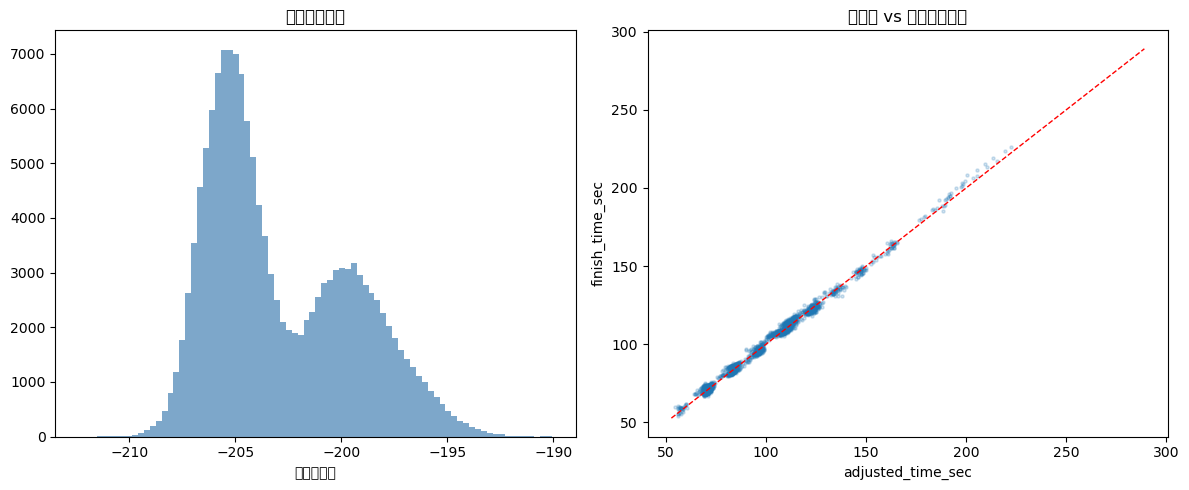


係数ファイル保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02/regression_params.json
{
  "model_version": "v1",
  "beta_pace": 0.8760043270756659,
  "beta_track": 0.19646834972204802,
  "beta_weight": 0.5498207833193652,
  "beta_level": 0.0,
  "tsi_mean": 3.3093199199583347,
  "r2_adj": 0.9393365074341149,
  "n_train": 145924,
  "fitted_at": "2026-07-10T14:15:53.370614"
}


In [9]:
# ── 残差プロット ─────────────────────────────────────────────────────
df_train_merged['predicted'] = (
    intercept
    + beta_pace * df_train_merged['front_split_dev'].fillna(0)
    + beta_tsi * (df_train_merged['tsi_raw'].fillna(global_tsi_mean) - global_tsi_mean)
    + beta_weight * df_train_merged['weight_dev'].fillna(0) * df_train_merged['dist_scale'].fillna(1)
)
# + 固定効果（par_time で代入）
df_train_merged = df_train_merged.merge(
    par_time_cell[['distance','surface','direction','track_cat','par_time_sec']],
    on=['distance','surface','direction','track_cat'], how='left'
)
df_train_merged['predicted_full'] = df_train_merged['par_time_sec'].fillna(
    df_train_merged['finish_time_sec'].mean()
) + df_train_merged['predicted']

residuals = df_train_merged['finish_time_sec'] - df_train_merged['predicted_full']
print(f'残差 RMSE: {np.sqrt((residuals**2).mean()):.3f} 秒')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(residuals.dropna(), bins=80, color='steelblue', alpha=0.7)
axes[0].set_title('回帰残差分布')
axes[0].set_xlabel('残差（秒）')

# β₃ 検証: 距離別斤量係数
# 2000m を1.0として、1600m と 2400m での理論値比較
for dist in [1200, 1600, 2000, 2400]:
    scale = dist / 2000
    print(f'{dist}m: β₃×55×scale = {beta_weight * 55 * scale:.2f}秒')

axes[1].scatter(
    df_train_merged['adjusted_time_sec'].sample(min(2000,len(df_train_merged)), random_state=42),
    df_train_merged['finish_time_sec'].sample(min(2000,len(df_train_merged)), random_state=42),
    alpha=0.2, s=5
)
axes[1].set_xlabel('adjusted_time_sec')
axes[1].set_ylabel('finish_time_sec')
axes[1].set_title('補正後 vs 生走破タイム')
mn = df_train_merged[['finish_time_sec','adjusted_time_sec']].min().min()
mx = df_train_merged[['finish_time_sec','adjusted_time_sec']].max().max()
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'regression_validation.png', dpi=80)
plt.show()

# 係数まとめを保存
coef_summary = {
    'model_version': MODEL_VERSION,
    'beta_pace':   float(beta_pace),
    'beta_track':  float(beta_tsi),
    'beta_weight': float(beta_weight),
    'beta_level':  float(beta_level),
    'tsi_mean':    float(global_tsi_mean),
    'r2_adj':      float(model.rsquared_adj),
    'n_train':     int(len(df_regr)),
    'fitted_at':   datetime.now().isoformat(),
}
import json
with open(OUTPUT_DIR / 'regression_params.json', 'w') as f:
    json.dump(coef_summary, f, ensure_ascii=False, indent=2)
print('\n係数ファイル保存完了:', OUTPUT_DIR / 'regression_params.json')
print(json.dumps(coef_summary, indent=2))
